In [1]:
import nltk #Natural Language Toolkit
import re #Regular Expressions
import string
import emoji
import pandas as pd

import spacy 

from nltk.tokenize import word_tokenize,sent_tokenize
from spacy.lang.en.stop_words import STOP_WORDS

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
nltk.download('punkt')
nltk.download("punkt_tab")
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ELCOT\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ELCOT\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ELCOT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ELCOT\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Normal Python Splitation for ref

In [3]:
text= "Sakthi Shree is an enthusiastic girl 😊 who is learning Data Science 📚. She is currently doing a Data Science course at Ether Infotech 💻 and loves Python 🐍."

In [4]:
text.split()

['Sakthi',
 'Shree',
 'is',
 'an',
 'enthusiastic',
 'girl',
 '😊',
 'who',
 'is',
 'learning',
 'Data',
 'Science',
 '📚.',
 'She',
 'is',
 'currently',
 'doing',
 'a',
 'Data',
 'Science',
 'course',
 'at',
 'Ether',
 'Infotech',
 '💻',
 'and',
 'loves',
 'Python',
 '🐍.']

In [5]:
text.split(".")

['Sakthi Shree is an enthusiastic girl 😊 who is learning Data Science 📚',
 ' She is currently doing a Data Science course at Ether Infotech 💻 and loves Python 🐍',
 '']

NLP Preprocessing

Converting into lowercase

In [6]:
text=text.lower()
print(text)

sakthi shree is an enthusiastic girl 😊 who is learning data science 📚. she is currently doing a data science course at ether infotech 💻 and loves python 🐍.


Convert Emoji into words

In [7]:
text=emoji.demojize(text)
print(text)

sakthi shree is an enthusiastic girl :smiling_face_with_smiling_eyes: who is learning data science :books:. she is currently doing a data science course at ether infotech :laptop: and loves python :snake:.


Punctuation Removing

In [8]:
text=re.sub(r'[^\w\s]', '', text)
print(text)

sakthi shree is an enthusiastic girl smiling_face_with_smiling_eyes who is learning data science books she is currently doing a data science course at ether infotech laptop and loves python snake


White space removal

In [9]:
text = re.sub(r'\s+', ' ', text).strip()
print(text)

sakthi shree is an enthusiastic girl smiling_face_with_smiling_eyes who is learning data science books she is currently doing a data science course at ether infotech laptop and loves python snake


NLP Tokenization-splitation

In [10]:
from nltk.tokenize import word_tokenize
tokens = word_tokenize(text)
print(tokens)

['sakthi', 'shree', 'is', 'an', 'enthusiastic', 'girl', 'smiling_face_with_smiling_eyes', 'who', 'is', 'learning', 'data', 'science', 'books', 'she', 'is', 'currently', 'doing', 'a', 'data', 'science', 'course', 'at', 'ether', 'infotech', 'laptop', 'and', 'loves', 'python', 'snake']


Stop of words-to remove unnecessary words

In [11]:
from nltk.corpus import stopwords
stop_words = stopwords.words("english")
st_words = [word for word in tokens if word not in stop_words]
print(st_words)

['sakthi', 'shree', 'enthusiastic', 'girl', 'smiling_face_with_smiling_eyes', 'learning', 'data', 'science', 'books', 'currently', 'data', 'science', 'course', 'ether', 'infotech', 'laptop', 'loves', 'python', 'snake']


Stemming-to remove prefix and suffix from root word

In [12]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
stem_words = [stemmer.stem(word) for word in st_words]
print(stem_words)

['sakthi', 'shree', 'enthusiast', 'girl', 'smiling_face_with_smiling_ey', 'learn', 'data', 'scienc', 'book', 'current', 'data', 'scienc', 'cours', 'ether', 'infotech', 'laptop', 'love', 'python', 'snake']


Lemmatization-used for give proper dictionary words

In [13]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
lemma_words = [lemmatizer.lemmatize(word) for word in st_words]
print(lemma_words)

['sakthi', 'shree', 'enthusiastic', 'girl', 'smiling_face_with_smiling_eyes', 'learning', 'data', 'science', 'book', 'currently', 'data', 'science', 'course', 'ether', 'infotech', 'laptop', 'love', 'python', 'snake']


In [14]:
clean_text=" ".join(lemma_words)
print(clean_text)

sakthi shree enthusiastic girl smiling_face_with_smiling_eyes learning data science book currently data science course ether infotech laptop love python snake


Feature Extraction (Bag of words)

In [15]:
cv = CountVectorizer()
bow = cv.fit_transform([clean_text])
print(cv.get_feature_names_out())
print(bow.toarray())

['book' 'course' 'currently' 'data' 'enthusiastic' 'ether' 'girl'
 'infotech' 'laptop' 'learning' 'love' 'python' 'sakthi' 'science' 'shree'
 'smiling_face_with_smiling_eyes' 'snake']
[[1 1 1 2 1 1 1 1 1 1 1 1 1 2 1 1 1]]


TF-IDF

In [16]:
tfidf = TfidfVectorizer()
tfidf_result = tfidf.fit_transform([clean_text])
print(tfidf.get_feature_names_out())
print(tfidf_result.toarray())

['book' 'course' 'currently' 'data' 'enthusiastic' 'ether' 'girl'
 'infotech' 'laptop' 'learning' 'love' 'python' 'sakthi' 'science' 'shree'
 'smiling_face_with_smiling_eyes' 'snake']
[[0.20851441 0.20851441 0.20851441 0.41702883 0.20851441 0.20851441
  0.20851441 0.20851441 0.20851441 0.20851441 0.20851441 0.20851441
  0.20851441 0.41702883 0.20851441 0.20851441 0.20851441]]


In [17]:
for word in clean_text.split():
    indx = tfidf.vocabulary_.get(word)

    if indx is not None:
        print(word, tfidf.idf_[indx])

sakthi 1.0
shree 1.0
enthusiastic 1.0
girl 1.0
smiling_face_with_smiling_eyes 1.0
learning 1.0
data 1.0
science 1.0
book 1.0
currently 1.0
data 1.0
science 1.0
course 1.0
ether 1.0
infotech 1.0
laptop 1.0
love 1.0
python 1.0
snake 1.0


Embedding Process

In [1]:
from sklearn.manifold import TSNE #T-distributed Stochastic Neighbor Embedding
import sys
!{sys.executable} -m pip install gensim


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gensim.downloader as api #from gensim we take model named as api
print(api.info()['models'].keys())

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])


In [3]:
#glove-Global Vectors for word Representation
glove=api.load('glove-wiki-gigaword-100')#load the model,wiki-wikipedia(articles),giagaword(newdataset),
#100-for a single word like cat-100 vector values

In [4]:
glove['sing']

array([-0.24557 ,  0.5036  , -0.18018 , -0.66226 ,  0.26796 ,  1.1913  ,
       -0.86658 ,  0.033613, -0.031217, -0.26771 , -0.18715 ,  0.49953 ,
       -0.53884 ,  0.8555  , -0.031516, -0.92412 ,  0.56468 ,  0.44458 ,
       -0.37197 ,  0.3869  ,  0.58732 , -0.25851 , -0.2085  , -0.53022 ,
       -0.011997,  0.11178 , -0.92195 , -0.31911 ,  1.5292  ,  0.80267 ,
       -0.88901 ,  0.054051,  0.98104 ,  0.44106 , -0.25249 ,  0.38584 ,
        0.41951 ,  0.3743  ,  0.010268, -1.4199  ,  0.37172 ,  0.58083 ,
       -0.55317 , -0.033263,  0.14519 ,  0.34066 , -0.43268 , -0.7007  ,
        0.51387 , -1.2578  , -0.86926 , -0.37211 ,  0.72518 ,  0.13732 ,
       -0.35877 , -1.0388  ,  0.58953 ,  0.21689 ,  0.51927 ,  0.38103 ,
        0.13336 ,  1.2248  , -0.57749 , -0.70551 , -0.5294  ,  0.25746 ,
        0.89907 ,  0.45331 , -0.36341 ,  0.017261, -0.039879,  0.24255 ,
       -0.34305 , -0.83855 ,  0.056367, -0.013646, -0.86471 , -0.56915 ,
        0.69678 , -0.6308  , -0.11756 , -1.0834  , 

In [5]:
glove.most_similar("princess")

[('queen', 0.7947243452072144),
 ('duchess', 0.7281514406204224),
 ('diana', 0.7199068665504456),
 ('prince', 0.7070384621620178),
 ('daughter', 0.7013464570045471),
 ('sister', 0.6965084075927734),
 ('empress', 0.6771331429481506),
 ('niece', 0.6753577589988708),
 ('wife', 0.6647809743881226),
 ('elizabeth', 0.661222517490387)]

In [6]:
glove.most_similar(positive=['leader','beautiful'],negative=['boy'])

[('stunning', 0.5552046298980713),
 ('charismatic', 0.5486201047897339),
 ('magnificent', 0.5314347147941589),
 ('party', 0.5283643007278442),
 ('spectacular', 0.5225839018821716),
 ('prime', 0.5217238068580627),
 ('important', 0.5147985816001892),
 ('clear', 0.5059770345687866),
 ('impressive', 0.5008339285850525),
 ('democratic', 0.4942794740200043)]

In [7]:
import spacy
nlp=spacy.load("en_core_web_sm")
doc_pos=nlp(clean_text)
for token in doc_pos:
    print(token.text,"|",token.pos_,"|",spacy.explain(token.pos_))

NameError: name 'clean_text' is not defined

In [ ]:
doc_tag=nlp(clean_text)
for token in doc_pos:
    print(token.text,"|",token.tag_,"|",spacy.explain(token.tag_))

sakthi | NNP | noun, proper singular
shree | NNP | noun, proper singular
enthusiastic | JJ | adjective (English), other noun-modifier (Chinese)
girl | NN | noun, singular or mass
smiling_face_with_smiling_eyes | NN | noun, singular or mass
learning | VBG | verb, gerund or present participle
data | NNS | noun, plural
science | NN | noun, singular or mass
book | NN | noun, singular or mass
currently | RB | adverb
data | VBZ | verb, 3rd person singular present
science | NN | noun, singular or mass
course | NN | noun, singular or mass
ether | NNP | noun, proper singular
infotech | NNP | noun, proper singular
laptop | NN | noun, singular or mass
love | NN | noun, singular or mass
python | NN | noun, singular or mass
snake | NN | noun, singular or mass


In [8]:
et='Joseph Vijay become Chiefminister of Tamilnadu on May 10,2026.and also Actor in Tamil film Industry'

In [9]:
doc=nlp(et)
for ent in doc.ents:
        print(ent.text,"|",ent.label_,"|",spacy.explain(ent.label_))

Joseph Vijay | PERSON | People, including fictional
May 10,2026.and | DATE | Absolute or relative dates or periods
Tamil | GPE | Countries, cities, states


In [10]:
vocab = ['Police', 'Thief', 'king', 'queen', 'banana', 'apple', 'mango', 'fruit', 'Black', 'Blue','Green']
words = []
labels = []
for word in vocab:
    word = word.lower()
    if word in glove:
        words.append(glove[word])
        labels.append(word)

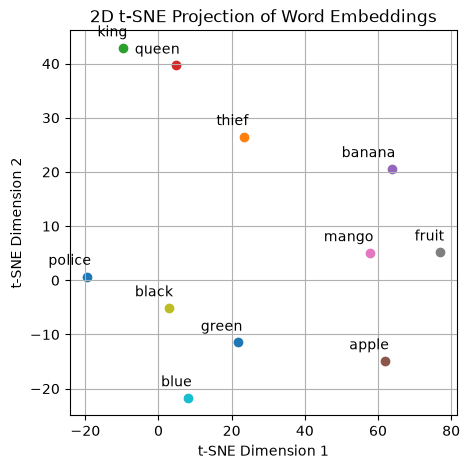

In [11]:
from sklearn.manifold import TSNE #high dimension → 2D convert , perplexity=5,n_components=2,init='pca'- starting point ,
import numpy as np
import matplotlib.pyplot as plt

tsne_model = TSNE(perplexity=5, n_components=2, init='pca', random_state=42)
coordinates = tsne_model.fit_transform(np.array(words)) #00 dimension vectors convert to 2 d

x_coords = coordinates[:, 0] # first and second columns - x and y split
y_coords = coordinates[:, 1]

plt.figure(figsize=(5, 5))
for i, word in enumerate(labels):
    plt.scatter(x_coords[i], y_coords[i])
    plt.annotate(word, (x_coords[i], y_coords[i]), xytext=(3, 6), # annotate → word name display
                 textcoords='offset points', ha='right', va='bottom')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("2D t-SNE Projection of Word Embeddings")
plt.grid(True)
plt.show()